## Акустические события

In [2]:
import os
import kagglehub

In [ ]:
os.environ["KAGGLE_API_TOKEN"] = os.getenv("KAGGLE_API_TOKEN")

In [4]:
path = kagglehub.competition_download('itmo-acoustic-event-detectin-2026')
print("Path to competition files:", path)

100%|██████████| 7.34G/7.34G [01:49<00:00, 72.0MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/itmo-acoustic-event-detectin-2026


In [5]:
competition_path = "/root/.cache/kagglehub/competitions/itmo-acoustic-event-detectin-2026"

train_folder = os.path.join(competition_path, "audio_train", "train")
train_csv = os.path.join(competition_path, "train.csv")

print(f"Аудиофайлов: {len(os.listdir(train_folder))}")
print(f"CSV: {os.path.exists(train_csv)}")

Аудиофайлов: 5683
CSV: True


In [ ]:
import random
import pickle
from enum import Enum
from typing import Optional, NoReturn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F_nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score
import torch.multiprocessing as mp
from tqdm import tqdm

from google.colab import files

In [7]:
def set_random_state(random_state: int = 42) -> NoReturn:
    torch.manual_seed(random_state)
    random.seed(random_state)
    np.random.seed(random_state)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        torch.cuda.manual_seed(random_state)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_random_state(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
os.environ['PYTHONHASHSEED'] = '42'
torch.use_deterministic_algorithms(True)

Device: cuda


In [ ]:
def extract_advanced_features(
    set_type: Enum,
    path_to_csv: str,
    path_to_files: str,
    out_path: str,
    labels_pickle: str,
    sr: int = 22050,          
    n_fft: int = 1024,
    hop_length: int = 512,     
    n_mels: int = 128,         
    fmax: Optional[int] = None,
    max_time_frames: int = 300
):
    """
    Извлекает мел-спектрограммы + дельты + дельта-дельты
    """
    if fmax is None:
        fmax = sr // 2

    if set_type.name == 'TRAIN':
        meta = pd.read_csv(path_to_csv, skiprows=1, names=['fname', 'label'])
        file_names = list(meta['fname'])
        labels = list(meta['label'])
        uniq_labels = np.sort(np.unique(labels))
        label_to_id = {label: i for i, label in enumerate(uniq_labels)}
        feats = []

        for fname, label in tqdm(zip(file_names, labels), total=len(file_names), desc="Extracting train features"):
            wav, _ = librosa.load(os.path.join(path_to_files, fname), sr=sr)

            # Мел-спектрограмма
            mel_spec = librosa.feature.melspectrogram(
                y=wav, sr=sr, n_fft=n_fft,
                hop_length=hop_length, n_mels=n_mels, fmax=fmax
            )
            log_mel = librosa.power_to_db(mel_spec, ref=np.max)

            # Дельта и дельта-дельта
            delta = librosa.feature.delta(log_mel, width=3)
            delta2 = librosa.feature.delta(log_mel, order=2, width=3)

            # Объединяем в 3 канала
            # Форма: (3, n_mels, time)
            features = np.stack([log_mel, delta, delta2], axis=0)

            # Приводим к фиксированной временной длине (обрезаем/дополняем нулями)
            if features.shape[2] < max_time_frames:
                pad_width = max_time_frames - features.shape[2]
                features = np.pad(features, ((0, 0), (0, 0), (0, pad_width)), mode='constant')
            else:
                features = features[:, :, :max_time_frames]

            feats.append({
                'fname': fname,
                'feature': features,
                'label_id': label_to_id[label]
            })

        pickle.dump(feats, open(out_path, 'wb'))
        pickle.dump(label_to_id, open(labels_pickle, 'wb'))
        return label_to_id

    else:
        feats = []
        for fname in tqdm(os.listdir(path_to_files), desc="Extracting test features"):
            wav, _ = librosa.load(os.path.join(path_to_files, fname), sr=sr)
            mel_spec = librosa.feature.melspectrogram(y=wav, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, fmax=fmax)
            log_mel = librosa.power_to_db(mel_spec, ref=np.max)
            delta = librosa.feature.delta(log_mel, width=3)
            delta2 = librosa.feature.delta(log_mel, order=2, width=3)
            features = np.stack([log_mel, delta, delta2], axis=0)

            if features.shape[2] < max_time_frames:
                pad_width = max_time_frames - features.shape[2]
                features = np.pad(features, ((0, 0), (0, 0), (0, pad_width)), mode='constant')
            else:
                features = features[:, :, :max_time_frames]

            feats.append({'fname': fname, 'feature': features})
        pickle.dump(feats, open(out_path, 'wb'))
        return

In [9]:
class SpecAugment:
    """Спектральная аугментация: маски по времени и частоте"""
    def __init__(self, freq_masks=2, freq_width=20, time_masks=2, time_width=40):
        self.freq_masks = freq_masks
        self.freq_width = freq_width
        self.time_masks = time_masks
        self.time_width = time_width

    def __call__(self, features):
        """
        features: (3, n_mels, time)
        применяем маски независимо к каждому из 3 каналов (мел, дельта, дельта2)
        """
        for c in range(features.shape[0]):
            # Частотные маски
            for _ in range(self.freq_masks):
                f0 = np.random.randint(0, features.shape[1] - self.freq_width)
                features[c, f0:f0+self.freq_width, :] = 0

            # Временные маски
            for _ in range(self.time_masks):
                t0 = np.random.randint(0, features.shape[2] - self.time_width)
                features[c, :, t0:t0+self.time_width] = 0
        return features

In [10]:
class AdvancedAudioDataset(Dataset):
    def __init__(self, x, y=None, augment=False, max_time_frames=300, spec_augment=None, device="cpu"):
        self.x = x
        self.y = y
        self.augment = augment
        self.max_time_frames = max_time_frames
        self.spec_augment = spec_augment
        self.device = device

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        feat = self.x[idx].copy()

        # Нормализация каналов
        for c in range(feat.shape[0]):
            mean = feat[c].mean()
            std = feat[c].std() + 1e-6
            feat[c] = (feat[c] - mean) / std

        # Аугментация
        if self.augment and self.spec_augment is not None:
            feat = self.spec_augment(feat)

        # Временной сдвиг
        if self.augment and random.random() > 0.5:
            shift = np.random.randint(-24, 25)
            feat = np.roll(feat, shift, axis=2)
            if shift > 0:
                feat[:, :, :shift] = 0
            elif shift < 0:
                feat[:, :, shift:] = 0

        feat_tensor = torch.tensor(feat, dtype=torch.float32, device=self.device)

        if self.y is not None:
            return feat_tensor, torch.tensor(self.y[idx], device=self.device)
        return feat_tensor

In [11]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.fc(x).view(x.size(0), x.size(1), 1, 1)
        return x * scale

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_se=True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels) if use_se else nn.Identity()

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F_nn.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        out = F_nn.relu(out)
        return out

class AdvancedAudioModel(nn.Module):
    def __init__(self, in_channels=3, num_classes=41, dropout=0.5):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        layers = [ResidualBlock(in_ch, out_ch, stride)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F_nn.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)

In [12]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F_nn.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

In [ ]:
class SetType(Enum):
    TRAIN = 1
    TEST = 2
    DEV = 3

label_to_id = extract_advanced_features(
    SetType.TRAIN,
    train_csv,
    train_folder,
    'train_advanced.pkl',
    'labels_advanced.pkl',
    sr=22050,
    n_fft=1024,
    hop_length=512,
    n_mels=128,
    max_time_frames=300
)

id_to_label = [label for label, _ in sorted(label_to_id.items(), key=lambda x: x[1])]
print(f"{len(label_to_id)} классов")

In [14]:
# Загрузка извлечённых признаков
train_data = pickle.load(open('train_advanced.pkl', 'rb'))
label_to_id = pickle.load(open('labels_advanced.pkl', 'rb'))
id_to_label = [label for label, _ in sorted(label_to_id.items(), key=lambda x: x[1])]

In [ ]:
all_features = [row['feature'] for row in train_data]
all_labels = [row['label_id'] for row in train_data]

sss = StratifiedShuffleSplit(n_splits=1, test_size=800, random_state=42)
train_idx, val_idx = next(sss.split(all_features, all_labels))

x_train = [all_features[i] for i in train_idx]
y_train = [all_labels[i] for i in train_idx]
x_val = [all_features[i] for i in val_idx]
y_val = [all_labels[i] for i in val_idx]

x_train = np.array(x_train)
x_val = np.array(x_val)
y_train = np.array(y_train)
y_val = np.array(y_val)

# Веса классов для Focal Loss
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

In [16]:
mp.set_start_method('spawn', force=True)

spec_aug = SpecAugment(freq_masks=2, freq_width=20, time_masks=2, time_width=40)

train_dataset = AdvancedAudioDataset(
    x_train, y_train, augment=True,
    max_time_frames=300, spec_augment=spec_aug, device=device
)
val_dataset = AdvancedAudioDataset(
    x_val, y_val, augment=False,
    max_time_frames=300, spec_augment=None, device=device
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

model = AdvancedAudioModel(in_channels=3, num_classes=len(label_to_id), dropout=0.3).to(device)

criterion = FocalLoss(gamma=2.0, alpha=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

scaler = torch.amp.GradScaler('cuda')

patience = 15
best_val_f1 = 0
patience_counter = 0
best_epoch = 0

train_losses = []
val_losses = []
train_f1_scores = []
val_f1_scores = []

for epoch in range(100):
    print(f"Epoch {epoch+1}")

    # Обучение
    model.train()
    epoch_train_loss = 0
    all_preds = []
    all_targets = []

    for batch_x, batch_y in tqdm(train_loader, desc="Train"):
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_train_loss += loss.item()
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())

    train_f1 = f1_score(all_targets, all_preds, average='weighted')  # weighted f1
    train_losses.append(epoch_train_loss / len(train_loader))
    train_f1_scores.append(train_f1)

    # Валидация
    model.eval()
    epoch_val_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in tqdm(val_loader, desc="Val"):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    val_f1 = f1_score(all_targets, all_preds, average='weighted')
    val_losses.append(epoch_val_loss / len(val_loader))
    val_f1_scores.append(val_f1)

    print(f"Train Loss: {train_losses[-1]:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss: {val_losses[-1]:.4f} | Val F1: {val_f1:.4f}")

    scheduler.step()

    # Сохраняем лучшую модель по F1-score
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model_advanced.pt')
        print(f" *** New best model! F1: {best_val_f1:.4f} ***")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest validation F1-score: {best_val_f1:.4f} at epoch {best_epoch}")

Epoch 1


Val: 100%|██████████| 13/13 [00:01<00:00,  8.95it/s]


Train Loss: 3.1576 | Train F1: 0.0778
Val Loss: 4.0686 | Val F1: 0.0544
 *** New best model! F1: 0.0544 ***
Epoch 2


Val: 100%|██████████| 13/13 [00:01<00:00,  9.06it/s]


Train Loss: 2.5925 | Train F1: 0.1642
Val Loss: 2.8665 | Val F1: 0.1348
 *** New best model! F1: 0.1348 ***
Epoch 3


...

Train Loss: 0.5434 | Train F1: 0.7202
Val Loss: 1.1322 | Val F1: 0.6423
Epoch 43


Val: 100%|██████████| 13/13 [00:01<00:00,  7.26it/s]


Train Loss: 0.5208 | Train F1: 0.7236
Val Loss: 1.2748 | Val F1: 0.5558
Epoch 44


Val: 100%|██████████| 13/13 [00:01<00:00,  8.28it/s]

Train Loss: 0.5134 | Train F1: 0.7291
Val Loss: 1.0521 | Val F1: 0.6490
Early stopping at epoch 44

Best validation F1-score: 0.6770 at epoch 29


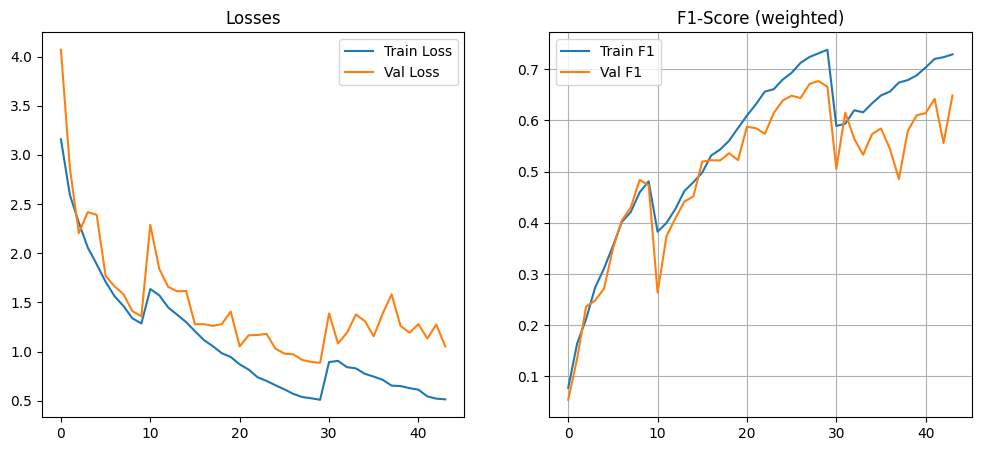

In [26]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Losses")

plt.subplot(1, 2, 2)
plt.plot(train_f1_scores, label='Train F1')
plt.plot(val_f1_scores, label='Val F1')
plt.legend()
plt.title("F1-Score (weighted)")
plt.grid(True)

plt.show()

## Проверка на тестовых данных

In [27]:
# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [29]:
# Метки классов
label_to_id = pickle.load(open('labels_advanced.pkl', 'rb'))
id_to_label = [label for label, _ in sorted(label_to_id.items(), key=lambda x: x[1])]
print(f"Classes: {len(id_to_label)}")

Classes: 41


In [30]:
# Пути к тестовым данным
competition_path = "/root/.cache/kagglehub/competitions/itmo-acoustic-event-detectin-2026"
test_folder = os.path.join(competition_path, "audio_test", "test")

if not os.path.exists(test_folder):
    test_folder = os.path.join(competition_path, "audio_test")

print(f"Test folder: {test_folder}")
test_files = sorted(os.listdir(test_folder))
print(f"Test files: {len(test_files)}")

Test folder: /root/.cache/kagglehub/competitions/itmo-acoustic-event-detectin-2026/audio_test/test
Test files: 3790


In [31]:
def extract_features_for_test(fname, sr=22050, n_fft=1024, hop_length=512, n_mels=128, max_time_frames=300):
    try:
        wav, _ = librosa.load(os.path.join(test_folder, fname), sr=sr)
    except:
        return np.zeros((3, n_mels, max_time_frames))

    fmax = sr // 2
    mel_spec = librosa.feature.melspectrogram(
        y=wav, sr=sr, n_fft=n_fft,
        hop_length=hop_length, n_mels=n_mels, fmax=fmax
    )
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)
    delta = librosa.feature.delta(log_mel, width=3)
    delta2 = librosa.feature.delta(log_mel, order=2, width=3)
    features = np.stack([log_mel, delta, delta2], axis=0)

    if features.shape[2] < max_time_frames:
        pad_width = max_time_frames - features.shape[2]
        features = np.pad(features, ((0, 0), (0, 0), (0, pad_width)), mode='constant')
    else:
        features = features[:, :, :max_time_frames]

    return features

# Извлечение признаков
print("\nИзвлечение признаков из тестовых файлов...")
test_features = []
for fname in tqdm(test_files):
    feat = extract_features_for_test(fname)
    test_features.append(feat)

test_features = np.array(test_features)
print(f"Features shape: {test_features.shape}")

# Нормализация
for i in range(len(test_features)):
    for c in range(test_features[i].shape[0]):
        mean = test_features[i][c].mean()
        std = test_features[i][c].std() + 1e-6
        test_features[i][c] = (test_features[i][c] - mean) / std


Извлечение признаков из тестовых файлов...


100%|██████████| 3790/3790 [01:25<00:00, 44.14it/s]


Features shape: (3790, 3, 128, 300)


In [ ]:
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, x):
        self.x = x
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return torch.tensor(self.x[idx], dtype=torch.float32)

test_dataset = TestDataset(test_features)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

# Загрузка модели
model = AdvancedAudioModel(in_channels=3, num_classes=len(id_to_label), dropout=0.3).to(device)
model.load_state_dict(torch.load('best_model_advanced.pt', map_location=device))
model.eval()
print("Модель загружена!")

# Предсказания
print("\nДелаем предсказания...")
all_preds = []
with torch.no_grad():
    for batch_x in tqdm(test_loader):
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())

predicted_labels = [id_to_label[p] for p in all_preds]

submission = pd.DataFrame({'fname': test_files, 'label': predicted_labels})
submission.to_csv('submission.csv', index=False)
print("\nsubmission.csv создан!")
print(f"Количество строк: {len(submission)}")
print(submission.head())

files.download('submission.csv')

Модель загружена!

Делаем предсказания...


100%|██████████| 60/60 [00:10<00:00,  5.93it/s]


submission.csv создан!
Количество строк: 3790
                      fname                  label
0  001e64cdd9984e165d34.wav                   Oboe
1  001e949afb7a313b4cfe.wav       Violin_or_fiddle
2  005e20afb8ba6b054afb.wav               Clarinet
3  007c5f37ab13c09bed62.wav              Harmonica
4  008736a59a001197a5d2.wav  Burping_or_eructation


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>